<a href="https://colab.research.google.com/github/tanveer-builds/Hospital-Ai/blob/main/GPT_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simplified Self Attension

convert the embedding vector to context vector

context vector is a enchired vector which contain the how much attenstion to give to whom

In [1]:
import torch

inputs = torch.tensor(
    [
        [0.43,0.15,0.89], # Your (x^1)
        [0.55,0.87,0.66], # journey (x^2)
        [0.57,0.85,0.64], # starts (x^3)
        [0.22,0.58,0.33], # with (x^4)
        [0.77,0.25,0.10], # one (x^5)
        [0.05,0.80,0.44] # step (x^6)
    ]
)

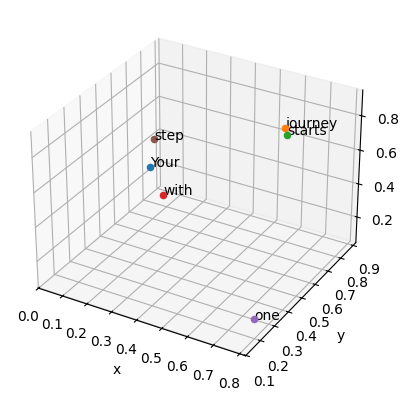

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

words = ['Your','journey','starts','with','one','step']

x_coords = inputs[:,0].numpy()
y_coords = inputs[:,1].numpy()
z_coords = inputs[:,2].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for x , y , z , word in zip(x_coords,y_coords,z_coords,words):
    ax.scatter(x,y,z)
    ax.text(x,y,z,word,fontsize=10)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()

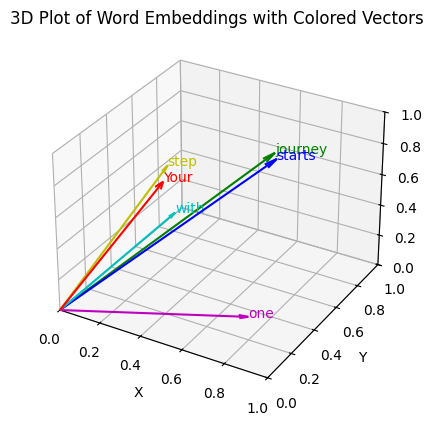

In [3]:
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()


In [4]:

query = inputs[1]

attn_score_2 = torch.empty(inputs.shape[0])

for i , x_i in enumerate(inputs):
  attn_score_2[i] = torch.dot(x_i,query)
print(attn_score_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0139])


**Note : attention score and attension weight are intuitively the same thing but the different. Attension Weight is normalized attenstion score**

In [5]:
attn_score_2_normalized = attn_score_2 / torch.sum(attn_score_2)
print("Attention weights =",attn_score_2_normalized)
print("Sum =",attn_score_2_normalized.sum())

Attention weights = tensor([0.1471, 0.2304, 0.2274, 0.1300, 0.1090, 0.1562])
Sum = tensor(1.0000)


*If there is a exterme value like array [1,2,3,400] normalized value is not good . we want no weighed to give to value lower value*

In [6]:
#using softmax

def softmax_naive(x):
  return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_score_2_normalized_naive = softmax_naive(attn_score_2)
print("Attention weights =",attn_score_2_normalized_naive)
print("Sum =",attn_score_2_normalized_naive.sum())

Attention weights = tensor([0.1401, 0.2406, 0.2359, 0.1254, 0.1094, 0.1487])
Sum = tensor(1.0000)


In [7]:
attn_score_2_normalized_softmax = torch.softmax(attn_score_2,dim=0)
print("Attention weights =",attn_score_2_normalized_softmax)
print("Sum =",attn_score_2_normalized_softmax.sum())

Attention weights = tensor([0.1401, 0.2406, 0.2359, 0.1254, 0.1094, 0.1487])
Sum = tensor(1.)


In [8]:
query = inputs[1]

context_vec_2 = torch.zeros(query.shape)

for i , x_i in enumerate(inputs):
  context_vec_2 += attn_score_2_normalized_softmax[i]*x_i

print(context_vec_2)

tensor([0.4463, 0.6498, 0.5522])


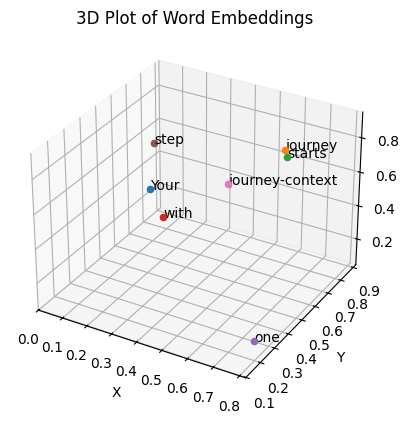

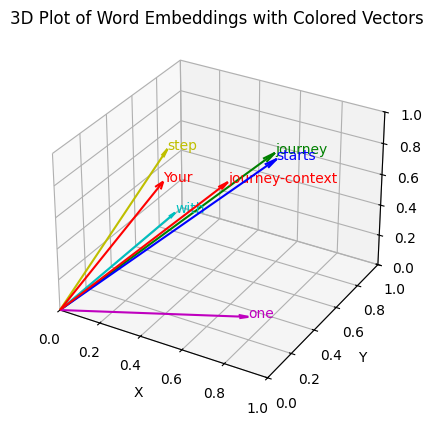

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55], # step     (x^6)
   [0.4419, 0.6515, 0.5683]]
)
# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

In [10]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]
   ]
)

In [11]:
attn_score = torch.empty(6,6)

for i , x_i in enumerate(inputs):
  for j , x_j in enumerate(inputs):
    attn_score[i,j] = torch.dot(x_i,x_j)

print(attn_score)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [12]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [13]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [14]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [15]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


In [16]:
print("Previous 2nd context vector:", context_vec_2)

Previous 2nd context vector: tensor([0.4463, 0.6498, 0.5522])


# Self Attention with trainable weights ( Scaled dot product attension )

In [17]:
import torch

inputs = torch.tensor(
    [
        [0.43,0.15,0.89], # Your (x^1)
        [0.55,0.87,0.66], # journey (x^2)
        [0.57,0.85,0.64], # starts (x^3)
        [0.22,0.58,0.33], # with (x^4)
        [0.77,0.25,0.10], # one (x^5)
        [0.05,0.80,0.44] # step (x^6)
    ]
)

In [18]:
x_2 = inputs[1] #A
d_in = inputs.shape[1] #B
d_out = 2 #C it can be same but for better understanding taking different output dimention

In [19]:
torch.manual_seed(123)
w_query = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
w_key = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
w_value = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)

In [20]:
print(w_query)
print(w_key)
print(w_value)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])
Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])
Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


In [21]:
query_2 = x_2 @ w_query
key_2 = x_2 @ w_key
value_2 = x_2 @ w_value

In [22]:

keys = inputs @ w_key
queries = inputs @ w_query
values = inputs @ w_value

In [23]:
keys_2 = keys[1] #A
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


In [24]:
attn_score_2 = query_2 @ keys.T
attn_score_2

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.4191])

In [25]:
attn_score = queries @ keys.T
attn_score

tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.0421],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.4191],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.4004],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.7789],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.6708],
        [0.8237, 1.2041, 1.1772, 0.7023, 0.3608, 0.9240]])

In [26]:
# attn_score /  d_k**0.5

In [27]:
attn_score[2].sum()

tensor(7.8871)

In [28]:
d_k = keys.shape[-1]
print(d_k)
## d_k**0.5 mean sqare root of d_k
attn_weight = torch.softmax(attn_score / d_k**0.5, dim=-1)
print(attn_weight)

2
tensor([[0.1569, 0.2128, 0.2083, 0.1429, 0.1086, 0.1706],
        [0.1524, 0.2299, 0.2233, 0.1331, 0.0920, 0.1692],
        [0.1527, 0.2291, 0.2226, 0.1336, 0.0928, 0.1693],
        [0.1604, 0.2011, 0.1979, 0.1490, 0.1217, 0.1700],
        [0.1622, 0.1964, 0.1937, 0.1512, 0.1275, 0.1691],
        [0.1586, 0.2076, 0.2036, 0.1456, 0.1143, 0.1703]])


<div class="alert alert-block alert-warning">

Reason 1: For stability in learning

The softmax function is sensitive to the magnitudes of its inputs. When the inputs are large, the differences between the exponential values of each input become much more pronounced. This causes the softmax output to become "peaky," where the highest value receives almost all the probability mass, and the rest receive very little.

In attention mechanisms, particularly in transformers, if the dot products between query and key vectors become too large (like multiplying by 8 in this example), the attention scores can become very large. This results in a very sharp softmax distribution, making the model overly confident in one particular "key." Such sharp distributions can make learning unstable,
    
</div>

In [29]:
import torch

tensor = torch.tensor([0.1,-0.2,0.3,-0.2,0.5])

#apply soft max

softmax_result = torch.softmax(tensor,dim=-1)

print(softmax_result)

# multiply the tensor by 8 and then apply softmax
scaled_tensor = tensor * 8
softmax_scaled_result = torch.softmax(scaled_tensor,dim=-1)
print(softmax_scaled_result)

tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


<div class="alert alert-block alert-warning">

Reason 2: To make the variance of the dot product stable

The dot product of  Q and K increases the variance because multiplying two random numbers increases the variance.

The increase in variance grows with the dimension.

Dividing by sqrt (dimension) keeps the variance close to 1
    
</div>

In [30]:
import numpy as np

# Function to compute variance before and after scaling
def compute_variance(dim, num_trials=1000):
    dot_products = []
    scaled_dot_products = []

    # Generate multiple random vectors and compute dot products
    for _ in range(num_trials):
        q = np.random.randn(dim)
        k = np.random.randn(dim)

        # Compute dot product
        dot_product = np.dot(q, k)
        dot_products.append(dot_product)

        # Scale the dot product by sqrt(dim)
        scaled_dot_product = dot_product / np.sqrt(dim)
        scaled_dot_products.append(scaled_dot_product)

    # Calculate variance of the dot products
    variance_before_scaling = np.var(dot_products)
    variance_after_scaling = np.var(scaled_dot_products)

    return variance_before_scaling, variance_after_scaling

# For dimension 5
variance_before_5, variance_after_5 = compute_variance(5)
print(f"Variance before scaling (dim=5): {variance_before_5}")
print(f"Variance after scaling (dim=5): {variance_after_5}")

# For dimension 20
variance_before_20, variance_after_20 = compute_variance(20)
print(f"Variance before scaling (dim=20): {variance_before_20}")
print(f"Variance after scaling (dim=20): {variance_after_20}")



Variance before scaling (dim=5): 5.212404415833546
Variance after scaling (dim=5): 1.042480883166709
Variance before scaling (dim=20): 19.383878224186535
Variance after scaling (dim=20): 0.9691939112093266


In [31]:
context_vec_2 = attn_weight[1] @ values
context_vec_2

tensor([0.3036, 0.8062])

Compact Python class

In [32]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):

  def __init__(self, d_in , d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in,d_out))
    self.W_key = nn.Parameter(torch.rand(d_in,d_out))
    self.W_value = nn.Parameter(torch.rand(d_in,d_out))

  def forward(self, x):
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value

    attn_score = queries @ keys.T
    attn_weight = torch.softmax(attn_score / keys.shape[-1]**0.5 ,dim=-1)

    context_vec = attn_weight @ values
    return context_vec

In [33]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in,d_out)
sa_v1(inputs)

tensor([[0.2971, 0.7900],
        [0.3036, 0.8062],
        [0.3033, 0.8054],
        [0.2923, 0.7785],
        [0.2903, 0.7737],
        [0.2950, 0.7849]], grad_fn=<MmBackward0>)

nn.LInear instead of manully implimented nn.Prameter has an optimized weight initialization scheme ,contribute to more stable and effective model training .

In [34]:
import torch.nn as nn
class SelfAttention_v2(nn.Module):

  def __init__(self, d_in , d_out,qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_key = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)

  def forward(self, x):
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    attn_score = queries @ keys.T
    attn_weight = torch.softmax(attn_score / keys.shape[-1]**0.5 ,dim=-1)

    context_vec = attn_weight @ values
    return context_vec

In [35]:
torch.manual_seed(123)
sa_v2 = SelfAttention_v2(d_in,d_out)
sa_v2(inputs)

tensor([[-0.5304, -0.1114],
        [-0.5286, -0.1147],
        [-0.5286, -0.1147],
        [-0.5258, -0.1145],
        [-0.5274, -0.1133],
        [-0.5254, -0.1153]], grad_fn=<MmBackward0>)

# Hidding Future Work using Masking Causal Attention

In [36]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_score = queries @ keys.T
attn_weights = torch.softmax(attn_score / keys.shape[-1]**0.5 , dim = -1)
attn_weights

tensor([[0.1721, 0.1766, 0.1765, 0.1559, 0.1631, 0.1557],
        [0.1638, 0.1752, 0.1748, 0.1614, 0.1607, 0.1641],
        [0.1639, 0.1751, 0.1748, 0.1614, 0.1608, 0.1640],
        [0.1637, 0.1704, 0.1702, 0.1652, 0.1633, 0.1671],
        [0.1669, 0.1724, 0.1723, 0.1619, 0.1635, 0.1629],
        [0.1618, 0.1700, 0.1698, 0.1665, 0.1627, 0.1691]],
       grad_fn=<SoftmaxBackward0>)

In [37]:
context_length = attn_score.shape[0]
mask_sample = torch.tril(torch.ones(context_length,context_length))
mask_sample = mask_sample * attn_weight

In [38]:
rows_sum = mask_sample.sum(dim=-1,keepdim=True)
masked_sample_norm = mask_sample / rows_sum
masked_sample_norm

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3986, 0.6014, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2526, 0.3791, 0.3683, 0.0000, 0.0000, 0.0000],
        [0.2265, 0.2839, 0.2794, 0.2103, 0.0000, 0.0000],
        [0.1952, 0.2363, 0.2331, 0.1820, 0.1534, 0.0000],
        [0.1586, 0.2076, 0.2036, 0.1456, 0.1143, 0.1703]])

# fixing problem of infulence of softmax

In [39]:
mask = torch.triu(torch.ones(context_length,context_length),diagonal=1)
mask

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])

In [40]:
masked = attn_scores.masked_fill(mask.bool(),-torch.inf)
masked

tensor([[0.9995,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.9544, 1.4950,   -inf,   -inf,   -inf,   -inf],
        [0.9422, 1.4754, 1.4570,   -inf,   -inf,   -inf],
        [0.4753, 0.8434, 0.8296, 0.4937,   -inf,   -inf],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654,   -inf],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

In [41]:
attn_weight = torch.softmax(masked / keys.shape[-1]**0.5,dim=-1)
attn_weight

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4056, 0.5944, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2566, 0.3741, 0.3693, 0.0000, 0.0000, 0.0000],
        [0.2176, 0.2823, 0.2796, 0.2205, 0.0000, 0.0000],
        [0.1826, 0.2178, 0.2191, 0.1689, 0.2115, 0.0000],
        [0.1473, 0.2033, 0.1996, 0.1500, 0.1160, 0.1839]])

Dropout ( 50 % )
mask out the 50 % of values to 0 and scale the other input by the 1 / 1- p . currently 2

In [42]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6,6)
dropout(example)

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])

In [43]:
torch.manual_seed(123)
dropout(attn_weight)

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5132, 0.7482, 0.7386, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.5646, 0.5592, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4357, 0.0000, 0.3378, 0.0000, 0.0000],
        [0.0000, 0.4065, 0.3991, 0.2999, 0.2320, 0.0000]])

## Compact python class

In [44]:
batch = torch.stack((inputs,inputs),dim=0)
batch.shape


torch.Size([2, 6, 3])

In [45]:
import torch.nn as nn
class Causal_Attention(nn.Module):

  def __init__(self, d_in , d_out, context_length , dropout ,qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_key = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))

  def forward(self, x):
    b , num_token , d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    attn_score = queries @ keys.transpose(1,2)
    attn_score.masked_fill(self.mask.bool()[:num_token,:num_token],-torch.inf)
    attn_weight = torch.softmax(attn_score / keys.shape[-1]**0.5 ,dim=-1)

    context_vec = attn_weight @ values
    return context_vec

In [46]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = Causal_Attention(d_in,d_out,context_length,0.0)
context_vec = ca(batch)
context_vec.shape

torch.Size([2, 6, 2])

In [47]:
context_vec

tensor([[[-0.5304, -0.1114],
         [-0.5286, -0.1147],
         [-0.5286, -0.1147],
         [-0.5258, -0.1145],
         [-0.5274, -0.1133],
         [-0.5254, -0.1153]],

        [[-0.5304, -0.1114],
         [-0.5286, -0.1147],
         [-0.5286, -0.1147],
         [-0.5258, -0.1145],
         [-0.5274, -0.1133],
         [-0.5254, -0.1153]]], grad_fn=<UnsafeViewBackward0>)

# Multi Head Attention

In [48]:
class MultiHeadAttentionWrapper(nn.Module):
  def __init__(self,d_in,d_out,context_length, dropout , num_heads , qkv_bias = False):
    super().__init__()
    self.heads = nn.ModuleList(
        [Causal_Attention(d_in,d_out,context_length,dropout,qkv_bias) for _ in range (num_heads)]
    )
  def forward(self , x):
    return torch.cat([head(x) for head in self.heads],dim=-1)

In [49]:
torch.manual_seed(123)
context_length = batch.shape[1]
d_in , d_out = 3,2
mha = MultiHeadAttentionWrapper(d_in,d_out,context_length,0.0,num_heads=96)
context_vec = mha(batch)
context_vec

tensor([[[-0.5304, -0.1114,  0.5032,  ..., -0.0394,  0.1276,  0.0439],
         [-0.5286, -0.1147,  0.5030,  ..., -0.0362,  0.1278,  0.0468],
         [-0.5286, -0.1147,  0.5030,  ..., -0.0365,  0.1278,  0.0469],
         [-0.5258, -0.1145,  0.5024,  ..., -0.0406,  0.1281,  0.0456],
         [-0.5274, -0.1133,  0.5029,  ..., -0.0440,  0.1276,  0.0477],
         [-0.5254, -0.1153,  0.5023,  ..., -0.0386,  0.1282,  0.0452]],

        [[-0.5304, -0.1114,  0.5032,  ..., -0.0394,  0.1276,  0.0439],
         [-0.5286, -0.1147,  0.5030,  ..., -0.0362,  0.1278,  0.0468],
         [-0.5286, -0.1147,  0.5030,  ..., -0.0365,  0.1278,  0.0469],
         [-0.5258, -0.1145,  0.5024,  ..., -0.0406,  0.1281,  0.0456],
         [-0.5274, -0.1133,  0.5029,  ..., -0.0440,  0.1276,  0.0477],
         [-0.5254, -0.1153,  0.5023,  ..., -0.0386,  0.1282,  0.0452]]],
       grad_fn=<CatBackward0>)

# Implementing multi head attention with weight splits

In [50]:
class MultiHeadAttention(nn.Module):
  def __init__(self,d_in,d_out,context_length, dropout , num_heads , qkv_bias = False):
    super().__init__()
    assert(d_out % num_heads == 0), \
    "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads

    self.W_query = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_key = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.out_proj = nn.Linear(d_out,d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))


  def forward(self , x):
    b , num_tokens , d_in = x.shape

    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    #We implicitly split the matrix by adding a num_head dimension
    #unroll last dim (b , num_token , d_out) -> ( b , num_token , num_heads , head_dim)
    keys = keys.view(b,num_tokens,self.num_heads , self.head_dim)
    queries = queries.view(b,num_tokens,self.num_heads , self.head_dim)
    values = values.view(b,num_tokens,self.num_heads , self.head_dim)

    # converting from ( b , num_token , num_heads , head_dim) -> ( b , num_heads , num_token , head_dim)
    keys = keys.transpose(1,2)
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    #cmpute scaled dot- product attention with causal mask
    attn_score = queries @ keys.transpose(2,3)

    mask_bool = self.mask.bool()[:num_tokens,:num_tokens]

    attn_score.masked_fill(mask_bool, -torch.inf)

    attn_weight = torch.softmax(attn_score / keys.shape[-1]**0.5 ,dim=-1)
    attn_weight = self.dropout(attn_weight)

    context_vec = (attn_weight @ values).transpose(1,2)

    context_vec = context_vec.contiguous().view(b,num_tokens,self.d_out)
    context_vec = self.out_proj(context_vec)

    return context_vec

In [51]:
torch.manual_seed(123)

inputs = torch.tensor(
    [[0.43, 0.15, 0.89, 0.55, 0.87, 0.66],  # Row 1
     [0.57, 0.85, 0.64, 0.22, 0.58, 0.33],  # Row 2
     [0.77, 0.25, 0.10, 0.05, 0.80, 0.55]]  # Row 3
)

batch = torch.stack((inputs,inputs),dim=0)
print(batch.shape)

batch_size , context_length , d_in = batch.shape
d_out = 6
mha = MultiHeadAttention(d_in,d_out,context_length,0.0,num_heads=2)
context_vecs = mha(batch)
context_vec

torch.Size([2, 3, 6])


tensor([[[-0.5304, -0.1114,  0.5032,  ..., -0.0394,  0.1276,  0.0439],
         [-0.5286, -0.1147,  0.5030,  ..., -0.0362,  0.1278,  0.0468],
         [-0.5286, -0.1147,  0.5030,  ..., -0.0365,  0.1278,  0.0469],
         [-0.5258, -0.1145,  0.5024,  ..., -0.0406,  0.1281,  0.0456],
         [-0.5274, -0.1133,  0.5029,  ..., -0.0440,  0.1276,  0.0477],
         [-0.5254, -0.1153,  0.5023,  ..., -0.0386,  0.1282,  0.0452]],

        [[-0.5304, -0.1114,  0.5032,  ..., -0.0394,  0.1276,  0.0439],
         [-0.5286, -0.1147,  0.5030,  ..., -0.0362,  0.1278,  0.0468],
         [-0.5286, -0.1147,  0.5030,  ..., -0.0365,  0.1278,  0.0469],
         [-0.5258, -0.1145,  0.5024,  ..., -0.0406,  0.1281,  0.0456],
         [-0.5274, -0.1133,  0.5029,  ..., -0.0440,  0.1276,  0.0477],
         [-0.5254, -0.1153,  0.5023,  ..., -0.0386,  0.1282,  0.0452]]],
       grad_fn=<CatBackward0>)

# Coding Dummy Gpt for now we will expand on it later

In [52]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [53]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

Step 1 : Tokentization

In [54]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


Initalizing DummyGptModel

In [55]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


# Layer Normatlization

its lead to stablitity in the training . so the gradient do no explode and implode . lead to stable training

If not it will take a long to time . it hault to training .  

In [56]:
torch.manual_seed(123)
batch_example = torch.randn(2,5)
layer = nn.Sequential(nn.Linear(5,6),nn.ReLU())
out = layer(batch_example)
out.mean(dim=-1,keepdim=True) , out.var(dim=-1,keepdim=True)

(tensor([[0.1324],
         [0.2170]], grad_fn=<MeanBackward1>),
 tensor([[0.0231],
         [0.0398]], grad_fn=<VarBackward0>))

This is how noramlization happen

In [57]:
out = (out - out.mean(dim=-1,keepdim=True)) / torch.sqrt(out.var(dim=-1,keepdim=True))
out

tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)

In [58]:
torch.set_printoptions(sci_mode=False)

In [59]:
out.mean(dim=-1,keepdim=True) , out.var(dim=-1,keepdim=True)

(tensor([[0.0000],
         [0.0000]], grad_fn=<MeanBackward1>),
 tensor([[1.0000],
         [1.0000]], grad_fn=<VarBackward0>))

Now making it into a class

In [60]:
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
     super().__init__()
     self.eps = 1e-5
     self.scale = nn.Parameter(torch.ones(emb_dim))
     self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self,x):
    norm_x = ( x - x.mean(dim=-1,keepdim=True)) / torch.sqrt(x.var(dim=-1,keepdim=True,unbiased=False) + self.eps)
    return self.scale * norm_x + self.shift

when unbiased = True . we do bessels correction . we divide by 1/(n-1) in variance calculation

In [61]:
ln = LayerNorm(emb_dim=5)
out = ln(batch_example)
out.mean(dim=-1,keepdim=True) , out.var(dim=-1,keepdim=True)

(tensor([[-0.0000],
         [ 0.0000]], grad_fn=<MeanBackward1>),
 tensor([[1.2499],
         [1.2500]], grad_fn=<VarBackward0>))

Gelu Activation Function

In [62]:
from IPython.display import display, Math

display(Math(r"GELU(x) = x \cdot \Phi(x)"))

display(Math(
    r"GELU(x) \approx 0.5x\left(1 + \tanh\left(\sqrt{\frac{2}{\pi}}(x + 0.044715x^3)\right)\right)"
))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [63]:
class GELU(nn.Module):
  def __init__(self, *args, **kwargs) -> None:
     super().__init__(*args, **kwargs)

  def forward(self,x):
    return 0.5 * x * ( 1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) *
           (x + 0.44725 * torch.pow(x,3))
    ));

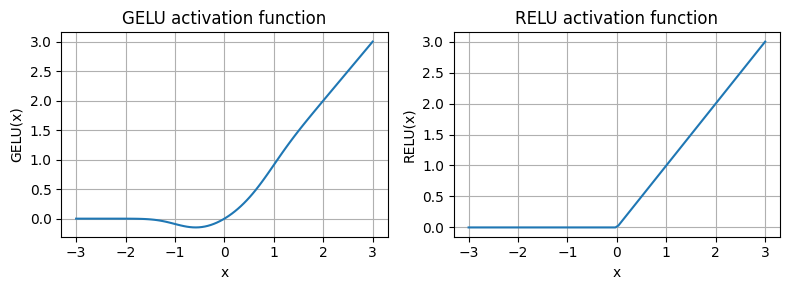

In [64]:
import matplotlib.pyplot as plt

gelu , relu  = GELU() , nn.ReLU()

x = torch.linspace(-3,3,100)

y_gelu , y_relu = gelu(x) , relu(x)

plt.figure(figsize=(8,3))

for i ,(y,label) in enumerate(zip([y_gelu,y_relu],["GELU","RELU"]),1):
  plt.subplot(1,2,i)
  plt.plot(x,y)
  plt.title(f"{label} activation function")
  plt.xlabel("x")
  plt.ylabel(f"{label}(x)")
  plt.grid(True)

plt.tight_layout()
plt.show()

In [65]:
class FeedForward(nn.Module):
  def __init__(self,cfg):
     super().__init__()
     self.layers = nn.Sequential(
         nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
         GELU(),
         nn.Linear(4 * cfg["emb_dim"],cfg["emb_dim"])
     )

  def forward(self , x):
    return self.layers(x)

Shorcut Connection

In [66]:
print(GPT_CONFIG_124M)

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}


In [67]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2,3,768)
out = ffn(x)
out.shape

torch.Size([2, 3, 768])

In [68]:
class ExampleDeepNeuralNetwork(nn.Module):
  def __init__(self,layer_sizes,use_shortcut):
     super().__init__()

     self.use_shortcut = use_shortcut
     self.layers = nn.ModuleList([
         nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1],GELU())),
         nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2],GELU())),
         nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3],GELU())),
         nn.Sequential(nn.Linear(layer_sizes[3],layer_sizes[4],GELU())),
         nn.Sequential(nn.Linear(layer_sizes[4],layer_sizes[5],GELU())),
     ])
  def forward(self,x):
    for layer in self.layers:
      layer_output = layer(x)

      if self.use_shortcut and x.shape == layer_output.shape:
        x = x + layer_output
      else:
        x = layer_output
    return x


In [69]:
layer_sizes = [3,3,3,3,3,1]

sample_input = torch.tensor([[1.,0.,-1.]])

torch.manual_seed(123)

model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes,use_shortcut=False)


In [70]:
def print_gradients(model,x):

  output = model(x)
  target = torch.tensor([[0.]])

  loss = nn.MSELoss()
  loss = loss(output,target)

  loss.backward()

  for name , param in model.named_parameters():
    if 'weight' in name :
      print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [71]:
print_gradients(model_without_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.001531339017674327
layers.1.0.weight has gradient mean of 0.0008734675939194858
layers.2.0.weight has gradient mean of 0.0021116069983690977
layers.3.0.weight has gradient mean of 0.0030934528913348913
layers.4.0.weight has gradient mean of 0.00788064580410719


In [72]:
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes,use_shortcut=True
)

print_gradients(model_with_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.24866615235805511
layers.1.0.weight has gradient mean of 0.8006525039672852
layers.2.0.weight has gradient mean of 0.38361984491348267
layers.3.0.weight has gradient mean of 0.3954206109046936
layers.4.0.weight has gradient mean of 1.001085877418518


Building Block of Transformers


In [73]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 256, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [74]:
class MultiHeadAttention(nn.Module):
  def __init__(self,d_in,d_out,context_length, dropout , num_heads , qkv_bias = False):
    super().__init__()
    assert(d_out % num_heads == 0), \
    "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads

    self.W_query = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_key = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.out_proj = nn.Linear(d_out,d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))


  def forward(self , x):
    b , num_tokens , d_in = x.shape

    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    #We implicitly split the matrix by adding a num_head dimension
    #unroll last dim (b , num_token , d_out) -> ( b , num_token , num_heads , head_dim)
    keys = keys.view(b,num_tokens,self.num_heads , self.head_dim)
    queries = queries.view(b,num_tokens,self.num_heads , self.head_dim)
    values = values.view(b,num_tokens,self.num_heads , self.head_dim)

    # converting from ( b , num_token , num_heads , head_dim) -> ( b , num_heads , num_token , head_dim)
    keys = keys.transpose(1,2)
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    #cmpute scaled dot- product attention with causal mask
    attn_score = queries @ keys.transpose(2,3)

    mask_bool = self.mask.bool()[:num_tokens,:num_tokens]

    attn_score.masked_fill(mask_bool, -torch.inf)

    attn_weight = torch.softmax(attn_score / keys.shape[-1]**0.5 ,dim=-1)
    attn_weight = self.dropout(attn_weight)

    context_vec = (attn_weight @ values).transpose(1,2)

    context_vec = context_vec.contiguous().view(b,num_tokens,self.d_out)
    context_vec = self.out_proj(context_vec)

    return context_vec

noraalization = x * mean / sqrt(var)

var = x - sum ( xi - mean )^2 / n

In [75]:
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
     super().__init__()
     self.eps = 1e-5
     self.scale = nn.Parameter(torch.ones(emb_dim))
     self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self,x):
    norm_x = ( x - x.mean(dim=-1,keepdim=True)) / torch.sqrt(x.var(dim=-1,keepdim=True,unbiased=False) + self.eps)
    return self.scale * norm_x + self.shift

class GELU(nn.Module):
  def __init__(self, *args, **kwargs) -> None:
     super().__init__(*args, **kwargs)

  def forward(self,x):
    return 0.5 * x * ( 1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) *
           (x + 0.44725 * torch.pow(x,3))
    ));
class FeedForward(nn.Module):
  def __init__(self,cfg):
     super().__init__()
     self.layers = nn.Sequential(
         nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
         GELU(),
         nn.Linear(4 * cfg["emb_dim"],cfg["emb_dim"])
     )

  def forward(self , x):
    return self.layers(x)


In [76]:
class TransformerBlock(nn.Module):

  def __init__(self,cfg):
    super().__init__()

    self.att = MultiHeadAttention(
        d_in = cfg["emb_dim"],
        d_out = cfg["emb_dim"],
        context_length = cfg["context_length"],
        num_heads=cfg["n_heads"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"]
    )
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self, x):

    shortcut = x
    x = self.norm1(x)
    x = self.att(x)
    x = self.drop_shortcut(x)
    x = x + shortcut

    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_shortcut(x)
    x = x + shortcut

    return x

Coding the entire gpt architecture


In [77]:
class GPTModel(nn.Module):

  def __init__(self, cfg) -> None:
     super().__init__()

     self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
     self.pos_emb = nn.Embedding(cfg["context_length"],cfg["emb_dim"])
     self.drop_emb = nn.Dropout(cfg["drop_rate"])

     self.trf_blocks = nn.Sequential(
         *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
     )

     self.final_norm = LayerNorm(cfg["emb_dim"])
     self.out_head = nn.Linear(
         cfg["emb_dim"],cfg["vocab_size"],bias=False
     )

  def forward(self, in_idx):
    batch_size , seq_len = in_idx.shape
    token_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len,device=in_idx.device))
    x = token_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits


In [78]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print(batch)
print(out.shape)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4, 50257])


In [79]:
# printing the total no of paramerter of the gpt model
total_param = sum(p.numel() for p in model.parameters())
total_param

162419712

but you can see the we have 163 milion parameter but in gpt there are 124 million because it reuses the embedding parameter we did not reuse it .

In [80]:
print(f"Token embedding layer shape",model.tok_emb.weight.shape)
print(f"Output layer shape",model.out_head.weight.shape)

Token embedding layer shape torch.Size([50257, 768])
Output layer shape torch.Size([50257, 768])


as you can see both the layers are exact same

In [81]:
total_param_gpt2 = total_param - sum(p.numel() for p in model.out_head.parameters())
total_param_gpt2

123822336

after removing the architecture. you can see it is now 124 million

but having seperate layer will result to the better model performance .

In [82]:
total_size_bytes = total_param * 4
total_size_mb = total_size_bytes / (1024*1024)
print(total_size_mb,"MB")

619.58203125 MB


#now we are going to generate the text fro model

In [83]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
  #idx is (batch , n_token)
  for _ in range(max_new_tokens):

    #crop current context if it execceds the supported context size
    idx_cond = idx[:,-context_size:]

    with torch.no_grad():
      logits = model(idx_cond)

    logits = logits[:,-1,:]

    probas = torch.softmax(logits,dim=-1)

    idx_next = torch.argmax(probas,dim=-1,keepdim=True)

    idx = torch.cat((idx,idx_next),dim=1)

  return idx


In [84]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print(encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print(encoded_tensor.shape)

[15496, 11, 314, 716]
torch.Size([1, 4])


In [85]:
model.eval()
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print(out)


tensor([[15496,    11,   314,   716, 13240, 11381, 20180, 25405, 17434, 17853]])


In [86]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Laur inhabElementم refres Rex


In [87]:
import tiktoken

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text,allowed_special={'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_id, tokenizer):
  flat = token_id.squeeze(0)
  return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context,tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"],
)

print(f"output text { token_ids_to_text(token_ids,tokenizer) }")

output text Every effort moves you rentingetic minion mobilized Macicone warrantyuler anim supra


loss function


In [88]:
inputs = torch.tensor([[16833, 3626, 6100],
                       [40, 1107, 588]])

targets = torch.tensor([[3626, 6100, 345],
                       [1107, 588, 11311]])

In [89]:
with torch.no_grad():
  logits = model(inputs)

probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [90]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print(f"Token Ids : {token_ids}")

Token Ids : tensor([[[36195],
         [16031],
         [42826]],

        [[25050],
         [ 7822],
         [16637]]])


In [91]:
print(token_ids_to_text(targets[0],tokenizer))
print(token_ids_to_text(token_ids[0].flatten(),tokenizer))

 effort moves you
lif savesNetflix


cross entropy loss

In [92]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1 :", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1 :", target_probas_2)

Text 1 : tensor([0.0000, 0.0000, 0.0000])
Text 1 : tensor([0.0000, 0.0000, 0.0000])


In [93]:
log_probas = torch.log(torch.cat((target_probas_1,target_probas_2)))

In [94]:
avg_log_probas = torch.mean(log_probas)
avg_log_probas

tensor(-10.9958)

In [95]:
neg_avg_log_probas = avg_log_probas * -1
neg_avg_log_probas

tensor(10.9958)

alternative

In [96]:
logits_flat = logits.flatten(0, 1)
target_flat = targets.flatten()

logits_flat.shape , target_flat.shape

(torch.Size([6, 50257]), torch.Size([6]))

In [97]:
loss = torch.nn.functional.cross_entropy(logits_flat, target_flat)
loss

tensor(10.9958)

perplexity : it mean the exponential of the cross entropy loss

In [98]:
perplexity = torch.exp(loss)
perplexity

tensor(59620.9258)

Downloading the dataset . it will require a lot of computer to train so we are using a small dataset

In [99]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
  with urllib.request.urlopen(url) as response:
    text_data = response.read().decode('utf-8')
  with open(file_path, "w", encoding="utf-8") as file:
    file.write(text_data)

else:
  with open(file_path, 'r', encoding="utf-8") as file:
    text_data = file.read()

In [100]:
text_data

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)\n\n"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it\'s going to send the value of my picture \'way up; but I don\'t think of that, Mr. Rickham--the loss to Arrt is all I think of." The word, on Mrs. Thwing\'s lips, multiplied its _rs_ as though they were reflected in an endless vista of mirrors. And it was not only the Mrs. Thwings who mourned. Had not the exquisite Hermia Croft, at the last Grafton Gallery show, stopped me before Gisburn\'s "Moon-dancers" to say, with tears in her eyes: "We shall not look upon its like again"?\n\nWell!--even 

In [101]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

total_characters , total_tokens

(20479, 5145)

In [102]:
from pygments import token
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):

  def __init__(self, txt, tokenizer, max_length, stride) -> None:
    super().__init__()

    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    for i in range(0, len(token_ids) - max_length , stride):
      input_chunk = token_ids[i:i+max_length]
      target_chunk = token_ids[i+1:i+max_length+1]

      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, index):
    return self.input_ids[index],self.target_ids[index]

In [103]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):

  tokenizer = tiktoken.get_encoding("gpt2")

  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  dataloader = DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=shuffle,
      drop_last=drop_last,
      num_workers=num_workers
  )

  return dataloader

In [104]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)


In [105]:
# sanity test

if total_tokens * (train_ratio) < GPT_CONFIG_124M['context_length']:
  print("not enought tokens for the training loader")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M['context_length']:
  print("not enought tokens for the validataion loader")

In [106]:
print("Train loader: ")
for x , y in train_loader:
  print(x.shape, y.shape)

print("Val loader: ")
for x , y in val_loader:
  print(x.shape, y.shape)

Train loader: 
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Val loader: 
torch.Size([2, 256]) torch.Size([2, 256])


In [107]:
train_tokens = 0

for input_batch , target_batch in train_loader:
  train_tokens += input_batch.numel()

val_tokens = 0

for input_batch , target_batch in val_loader:
  val_tokens += input_batch.numel()

train_tokens, val_tokens

(4608, 512)

In [108]:
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [110]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch, target_batch = input_batch.to(device), target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
  return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0

  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    # reduce the number of batches to match the total number of batches in the data loader
    # if num_batches exceeds the number of batches in data loader
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      total_loss += loss.item()
    else:
      break
  return total_loss / num_batches


In [111]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [113]:
torch.manual_seed(123)

with torch.no_grad():
  train_loss = calc_loss_loader(train_loader, model, device)
  val_loss = calc_loss_loader(val_loader, model, device)

train_loss, val_loss

(11.003059281243218, 10.992372512817383)